# **VMC Simulation of Superfluid 4He**
### QMC Final Project

By: **Joaquín Gabriel Márquez Olguín**

Course 2025/26

**Goal:** Determine the ground state energy and structural properties of Superfluid Helium-4 in a 3D box with Periodic Boundary Conditions (PBC) using the Variational Monte Carlo (VMC) method. We will model the interatomic interactions using the Aziz II potential and optimize a Jastrow-type trial wave function.

**Physical System**

We consider a system of $N$ Helium-4 atoms (bosons) in a cubic box of volume $V = L^3$ at density $\rho = N/V$.The Hamiltonian is:$$\hat{H} = -\frac{\hbar^2}{2m} \sum_{i=1}^{N} \nabla_i^2 + \sum_{i<j}^{N} V(r_{ij})$$

The Hamiltonian of the system is:

$$\hat{H} = -\frac{\hbar^2}{2m} \sum_{i=1}^{N} \nabla_i^2 + \sum_{i<j}^{N} V(r_{ij}).$$

* The **Interaction Potential** $V(r_{ij})$ is given by the Aziz II potential (proposed by Aziz et al.), which accurately captures the He-He interaction. It takes the form:

    $$V(r) = \epsilon \left[ A \exp(-\alpha_p x +\beta x^2) - F(x) \left( \frac{C_6}{x^6} + \frac{C_8}{x^8} + \frac{C_{10}}{x^{10}} \right)\right],$$

    where $x = r / r_m$, and the damping function $F(x)$ handles the short-range behavior:
    
    $$
    F(x) = \begin{cases} 
    \exp \left[ -\left( \frac{D}{x} - 1 \right)^2 \right] & \text{if } x < D \\
    1 & \text{if } x \ge D
    \end{cases}
    $$

    The parameters are given in the following table:


    | Parameter | Value | Unit | Description |
    | :--- | :--- | :--- | :--- |
    | **$r_m$** | 2.963 | Å | Minimum potential distance |
    | **$\epsilon$** | 10.948 | K | Potential well depth |
    | **$A$** | $1.844 \times 10^5$ | - | Repulsive amplitude (dimensionless) |
    | **$\alpha$** | 10.433 | - | Repulsive decay constant |
    | **$\beta$** | -2.280 | - | Quadratic repulsive parameter |
    | **$D$** | 1.4826 | - | Damping cutoff parameter |
    | **$C_6$** | 1.367 | - | Dispersion coeff. (dimensionless) |
    | **$C_8$** | 0.421 | - | Dispersion coeff. (dimensionless) |
    | **$C_{10}$** | 0.175 | - | Dispersion coeff. (dimensionless) |

<p>&nbsp;</p>

**Implementation Details:**

* To simulate a bulk superfluid system using a finite number of particles $N$, we employ **Periodic Boundary Conditions (PBC)** in all three Cartesian directions:

    * The particles are confined to a cubic box of side length $L = (N/\rho)^{1/3}$.
    * When calculating the distance $r_{ij}$ between any pair of particles $i$ and $j$, we consider the shortest distance between particle $i$ and any periodic image of particle $j$:
        $$r_{ij} = \min_{\mathbf{n} \in \mathbb{Z}^3} |\mathbf{r}_i - \mathbf{r}_j - \mathbf{n}L|$$
        
        This ensures that the potential energy and trial wave function respects the periodicity of the box.

* We utilize a variational approach with a **trial wave function** $\Psi_T$ of the Jastrow pair-product form (which captures the strong two-body correlations induced by the hard core of the Helium potential):

    $$\Psi_T(\mathbf{R}) = \prod_{i<j}^{N} \exp \left[ -\left(\frac{\alpha}{|r_{ij}|}\right)^{\beta} \right],$$

    where $\alpha$ and $\beta$ in the project description are the variational parameters we will optimize to minimize the total energy.

**VMC and Energy Estimation:**

We use the Metropolis-Hastings algorithm to sample configurations $\mathbf{R}$ distributed according to the probability density $P(\mathbf{R}) = \frac{|\Psi_T(\mathbf{R})|^2}{\int |\Psi_T|^2 d\mathbf{R}}$.

To evaluate the ground state energy, we calculate the *Local Energy* $E_L(\mathbf{R})$ averaged over the sampled configurations. As we have seen, this estimator has the property that if $\Psi_T$ is the exact eigenstate, $E_L$ is constant and equal to the exact energy (zero variance property).

$$\langle E \rangle = \frac{1}{M} \sum_{k=1}^{M} E_L(\mathbf{R}_k)$$

The Local Energy is defined as:

$$E_L(\mathbf{R}) = \frac{\hat{H} \Psi_T(\mathbf{R})}{\Psi_T(\mathbf{R})} = -\frac{\hbar^2}{2m} \sum_{i=1}^N \frac{\nabla_i^2 \Psi_T}{\Psi_T} + V(\mathbf{R})$$

For the Jastrow form $\Psi = e^{-U}$ (where $U = \sum u(r_{ij})$), it is computationally efficient to split the kinetic term into a gradient squared term and a Laplacian term:

$$-\frac{\hbar^2}{2m} \frac{\nabla_i^2 \Psi_T}{\Psi_T} = -\frac{\hbar^2}{2m} \left[ \nabla_i^2 (-\ln \Psi_T) + (\nabla_i \ln \Psi_T)^2 \right]$$

This approach avoids numerical instabilities and allows us to monitor both the Kinetic and Potential contributions separately during the simulation (to better reafirm our simulation results).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

In [2]:
# PHYSICAL CONSTANTS & PARAMETERS
HBAR2_2M = 6.0596   # K * A^2 (hbar^2/2m_He)
RHO_HE = 0.0218     # Equilibrium density (atoms/A^3)


# HFD-B Form POTENTIAL PARAMETERS (as given by the Aziz 1987 paper)
RM = 2.963              # Angstrom
D_DAMP = 1.4826
A_REP = 1.844e5
ALPHA_P = 10.43329537
BETA_P = -2.27965105
C6 =  1.36745214
C8 = 0.42123807
C10 = 0.17473318
EPSILON = 10.948        # K

# HELPER FUNCTIONS

@njit
def pbc_dist(r1, r2, L):
    """
    Calculates the vector and scalar distance r_ij between two particles
    under Periodic Boundary Conditions
    """
    dx = r1[0] - r2[0]
    dy = r1[1] - r2[1]
    dz = r1[2] - r2[2]
    
    # Minimum Image Convention
    dx -= L * round(dx / L)
    dy -= L * round(dy / L)
    dz -= L * round(dz / L)

    r_vec = np.array([dx, dy, dz])
    r_scalar = np.sqrt(dx*dx + dy*dy + dz*dz)
    
    return r_vec, r_scalar

@njit
def psi_T(positions, L, alpha, beta):
    """
    Many-body trial wave function for N particles:
    Psi = Product_{i<j} exp( - alpha / r_ij^beta )
    """
    N = len(positions)
    exp_term = 0.0
    
    for i in range(N):
        for j in range(i + 1, N):
            _, r = pbc_dist(positions[i], positions[j], L)

            if r > 1e-12:
                exp_term -= (alpha / r)**beta
            else:
                return 0.0 # null overlap at large distances
                
    return np.exp(exp_term)

@njit
def log_probability(positions, L, alpha, beta):
    """
    Computes ln(|Psi|^2) = 2 * ln(Psi) 
                         = -2 * sum_{i<j} (alpha / r_ij^beta)
    """
    N = len(positions)
    log_prob = 0.0
    
    for i in range(N):
        for j in range(i + 1, N):
            _, r = pbc_dist(positions[i], positions[j], L)
            
            if r < 1e-12: 
                return -1e20 # Hard core overlap
            
            u = (alpha / r)**beta
            log_prob -= 2.0 * u
            
    return log_prob

# ENERGY + POTENTIAL

HBAR2_2M = 6.0596   # K * A^2 (hbar^2/2m_He)
RHO_HE = 0.0218     # Equilibrium density of He4 (atoms/A^3)

@njit
def local_energy(positions, L, alpha_var, beta_var):
    """
    Calculates Local Energy E_L = T_loc + V_loc
    T_loc = - (hbar^2/2m) * [ Sum_i (Lap_i ln Psi + |Grad_i ln Psi|^2) ]
    V_loc = Aziz II Potential
    """
    N = len(positions)
    
    potential_energy = 0.0
    kinetic_laplacian = 0.0
    kinetic_grad_sq = 0.0
    
    gradients = np.zeros((N, 3)) 
    
    # Loop over pairs
    for i in range(N):
        for j in range(i + 1, N):

            r_vec, _ = pbc_dist(positions[i], positions[j], L)
            r = np.linalg.norm(r_vec)
            
            if r < 1e-12: continue # Avoid div by zero
            
            # Aziz II PPOTENTIAL
            x = r / RM
            # Damping F(x)
            if x < D_DAMP:
                F = np.exp(-(D_DAMP/x - 1)**2)
            else:
                F = 1.0
            
            V_pair = EPSILON * ( A_REP * np.exp(-ALPHA_P * x + BETA_P * x**2) - 
                                F * (C6/x**6 + C8/x**8 + C10/x**10) )
            potential_energy += V_pair
            
            # KINETIC PART: LAPLACIAN + GRADIENT ESTIMATORS
            # u(r) = alpha / r^beta
            # ln Psi_T = - sum u(r)
            
            # u = alpha * r^(-beta)
            u_val = (alpha_var / r)**beta_var
            
            # u' = -beta * alpha * r^(-beta-1) = -beta * u / r
            du_dr = -beta_var * u_val / r
            
            # u'' = -beta * (-beta-1) * alpha * r^(-beta-2)
            #     = beta * (beta+1) * u / r^2
            d2u_dr2 = beta_var * (beta_var + 1) * u_val / (r**2)
            
            # Laplacian_i (ln Psi): 
            #   Lap(-u) = - (u'' + 2/r * u')
            lap_term = - (d2u_dr2 + (2.0/r)*du_dr)
            
            # Both particles i and j feel this laplacian scalar
            kinetic_laplacian += 2.0 * lap_term 
            
            # Gradient_i (ln Psi):
            #   Grad_i (-u) = -u' * (r_vec / r)
            grad_contribution = -du_dr * (r_vec / r)
            
            # Add vector contribution to i, subtract from j
            gradients[i] += grad_contribution
            gradients[j] -= grad_contribution
            
    # Sum squares of total gradients for each particle
    for i in range(N):
        kinetic_grad_sq += np.sum(gradients[i]**2)
        
    T_lap = -HBAR2_2M * (kinetic_laplacian + kinetic_grad_sq)
    T_grad = HBAR2_2M * kinetic_grad_sq
    
    return (potential_energy + T_lap), (potential_energy + T_grad)



# VMC ALGORITHM

@njit
def VMC_simulation(n_steps, N, alpha, beta, delta):
    """
    Runs Variational Monte Carlo simulation for Superfluid Helium.

    Inputs:
        n_steps        : number of MC steps to perform
        N              : number of particles
        alpha, beta    : variational parameters for the trial wavefunction
        delta          : maximum displacement for trial moves
    Outputs:
        energies_lap   : energy history (Laplacian estimator)
        energies_grad  : energy history (Drift Force/Gradient estimator)
        acceptance_rate: acceptance rate per step
        x_history      : history particle positions (N_steps, N, 3)
    """
    # 3D Simulation Box
    L = (N / RHO_HE)**(1.0/3.0)
    
    # Storage for results
    # We will sample energy less frequently to save time
    sample_interval = 20 
    n_samples = (n_steps // sample_interval) + 1

    energies_lap = np.zeros(n_samples)
    energies_grad = np.zeros(n_samples)
    acceptance_history = np.zeros(n_samples)
    x_history = np.zeros((n_samples, N, 3)) 

    # Initialized random positions in Box L
    x = np.random.rand(N, 3) * L

    accepted_moves = 0
    attempted_moves = 0

    # Calculate current (log) probability
    log_P_current = log_probability(x, L, alpha, beta)

    # MC loop
    sample_idx = 0
    for step in range(n_steps):
        # Propose a random move to just one random particle
        i_particle = np.random.randint(N)

        old_pos_i = x[i_particle].copy()

        dx = delta * (2.0 * np.random.rand(3) - 1.0)
        x[i_particle] += dx
        
        # Apply PBC to proposed positions
        for k in range(3):
            x[i_particle, k] -= L * np.floor(x[i_particle, k] / L)

        # Compute new (log) probability
        log_P_new = log_probability(x, L, alpha, beta)

        # Metropolis algorithm (Log version to avoind numerical instability)
        # Ratio A = P_new / P_old  ==>  ln(A) = ln(P_new) - ln(P_old)
        if (log_P_new - log_P_current) > np.log(np.random.rand()):
            # We keep x as it is now
            log_P_current = log_P_new
            accepted_moves += 1
        else:
            # Reject move (go back to old position)
            x[i_particle] = old_pos_i
        
        attempted_moves += 1
        
        # Measure Local Energy
        if step % sample_interval == 0:
            e_lap, e_grad = local_energy(x, L, alpha, beta)
        
            energies_lap[sample_idx] = e_lap
            energies_grad[sample_idx] = e_grad
            acceptance_history[sample_idx] = accepted_moves / attempted_moves
            x_history[sample_idx, :, :] = x.copy()
            
            accepted_moves = 0
            attempted_moves = 0
            sample_idx += 1
        
    return energies_lap[:sample_idx], energies_grad[:sample_idx], acceptance_history[:sample_idx], x_history[:sample_idx]

Now, we compute the Ground State (GS) Energy by finding the optimal varioational parameteres ($\alpha$, $\beta$) that minimize the expectation value of the Hamiltonian.

## **1. Optimization of variational parameters**

In order to do it, we first fix the value of $\beta$ and vary $\alpha$, and then we repeat it viceversa. In order to know what range of values to scan, we use the McMillan result of $\beta=5$ for the Lennard-Jones potential as a guide. We look for the minimum value of $\alpha$ in the range of 1 to 4, consistent with the optimal parameters obtained by Boronat and Casulleras (1994) using the same trial wave function. Once we have this value of $\alpha$, we repeat the scan fixing $\alpha$ and getting the optimal $\beta$, and so on until we get more or less consistent results. 

Some implementation details:
* We discard the first 20% of steps to allow the system to equilibrate from the random initial configuration.
* We calculate the mean energy and the statistical error.
* We choose ``DELTA'' parameter (proposed step size) such that the acceptance rate is between 20-80%.

Scanning Beta (Fixed Alpha = 2.83)
Beta: 3.00 | E/N: -1.7842 K | Acc: 53.4%
Beta: 3.08 | E/N: -1.9126 K | Acc: 52.9%
Beta: 3.17 | E/N: -3.2681 K | Acc: 52.1%
Beta: 3.25 | E/N: -4.0788 K | Acc: 51.9%
Beta: 3.33 | E/N: -3.9234 K | Acc: 51.6%
Beta: 3.42 | E/N: -4.3417 K | Acc: 50.3%
Beta: 3.50 | E/N: -5.2481 K | Acc: 50.3%
Beta: 3.58 | E/N: -4.9030 K | Acc: 49.3%
Beta: 3.67 | E/N: -5.2346 K | Acc: 49.2%
Beta: 3.75 | E/N: -5.5547 K | Acc: 48.5%
Beta: 3.83 | E/N: -5.6557 K | Acc: 48.4%
Beta: 3.92 | E/N: -5.4589 K | Acc: 47.6%
Beta: 4.00 | E/N: -5.7470 K | Acc: 46.9%
Beta: 4.08 | E/N: -5.5425 K | Acc: 46.9%
Beta: 4.17 | E/N: -5.5725 K | Acc: 46.2%
Beta: 4.25 | E/N: -5.5096 K | Acc: 46.1%
Beta: 4.33 | E/N: -5.2690 K | Acc: 46.0%
Beta: 4.42 | E/N: -5.4015 K | Acc: 44.8%
Beta: 4.50 | E/N: -5.2705 K | Acc: 44.8%
Beta: 4.58 | E/N: -4.6750 K | Acc: 44.4%
Beta: 4.67 | E/N: -4.9258 K | Acc: 43.8%
Beta: 4.75 | E/N: -4.5510 K | Acc: 43.8%
Beta: 4.83 | E/N: -4.3514 K | Acc: 43.5%
Beta: 4.92 | E/N: -4.4

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

Beta: 5.00 | E/N: -4.3452 K | Acc: 42.3%
Optimal Beta (at fixed alpha=2.83): 4.00 (E = -5.7470 K)


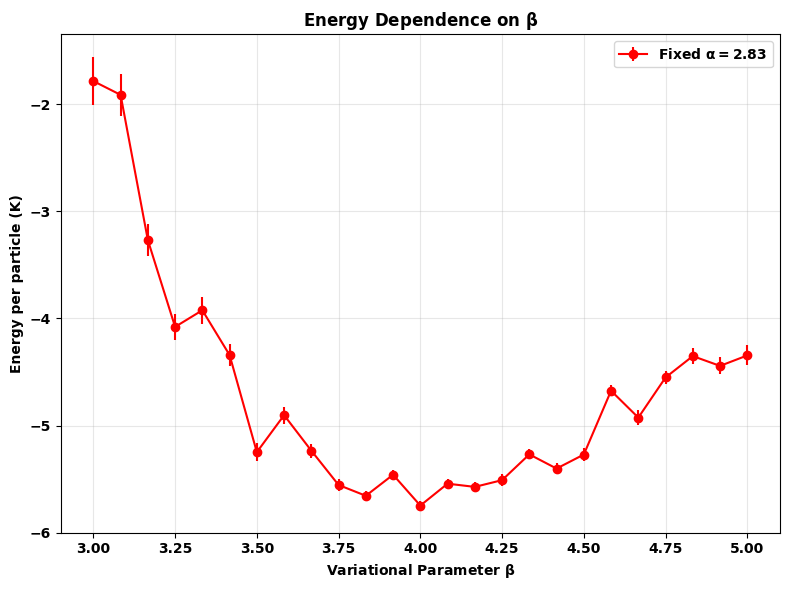

In [3]:
# Simulation Parameters
N_PARTICLES = 32         
N_STEPS = 50000          
DELTA = 1.0              

# SCAN BETA (Fixing Alpha)
fixed_alpha = 2.83
betas_scan = np.linspace(3, 5, 25)
energies_beta = []
errors_beta = []

print(f"Scanning Beta (Fixed Alpha = {fixed_alpha})")
for b in betas_scan:
    E_lap, _, acc_history, _ = VMC_simulation(N_STEPS, N_PARTICLES, fixed_alpha, b, DELTA)
    
    # we discard the first 20% of points
    burn_idx = int(len(E_lap) * 0.2)
    valid_E = E_lap[burn_idx:]
    
    E_mean = np.mean(valid_E)
    E_err = np.std(valid_E) / np.sqrt(len(valid_E))
    
    energies_beta.append(E_mean / N_PARTICLES)
    errors_beta.append(E_err / N_PARTICLES)

    acc = np.mean(acc_history[burn_idx:])
    
    print(f"Beta: {b:.2f} | E/N: {E_mean/N_PARTICLES:.4f} K | Acc: {acc:.1%}")

# Find best Beta
min_idx_beta = np.argmin(energies_beta)
best_beta = betas_scan[min_idx_beta]
min_E_beta = energies_beta[min_idx_beta]
print(f"Optimal Beta (at fixed alpha={fixed_alpha}): {best_beta:.2f} (E = {min_E_beta:.4f} K)")


# Plot 1: Energy vs Beta
plt.figure(figsize=(8, 6))
plt.errorbar(betas_scan, energies_beta, yerr=errors_beta, fmt='o-', color='red', label=f'Fixed $\\alpha={fixed_alpha}$')
plt.title(f"Energy Dependence on $\\beta$")
plt.xlabel(r"Variational Parameter $\beta$")
plt.ylabel("Energy per particle (K)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Scanning Alpha (Fixed Beta = 3.5)
Alpha: 2.00 | E/N: 54.1311 K | Acc: 68.4%
Alpha: 2.08 | E/N: 40.4362 K | Acc: 66.9%
Alpha: 2.17 | E/N: 30.1756 K | Acc: 65.3%
Alpha: 2.25 | E/N: 21.5918 K | Acc: 63.2%
Alpha: 2.33 | E/N: 14.3980 K | Acc: 61.0%
Alpha: 2.42 | E/N: 8.6454 K | Acc: 59.2%
Alpha: 2.50 | E/N: 4.2328 K | Acc: 57.1%
Alpha: 2.58 | E/N: 0.8547 K | Acc: 55.4%
Alpha: 2.67 | E/N: -1.8017 K | Acc: 53.1%
Alpha: 2.75 | E/N: -3.9185 K | Acc: 51.3%
Alpha: 2.83 | E/N: -5.1405 K | Acc: 49.8%
Alpha: 2.92 | E/N: -5.9160 K | Acc: 48.0%
Alpha: 3.00 | E/N: -6.5590 K | Acc: 45.9%
Alpha: 3.08 | E/N: -6.4170 K | Acc: 44.9%
Alpha: 3.17 | E/N: -6.4630 K | Acc: 42.9%
Alpha: 3.25 | E/N: -5.8869 K | Acc: 41.1%
Alpha: 3.33 | E/N: -5.5179 K | Acc: 39.1%
Alpha: 3.42 | E/N: -5.0761 K | Acc: 37.5%
Alpha: 3.50 | E/N: -4.1243 K | Acc: 35.7%
Alpha: 3.58 | E/N: -2.9352 K | Acc: 33.9%
Alpha: 3.67 | E/N: -2.4156 K | Acc: 32.3%
Alpha: 3.75 | E/N: -1.2083 K | Acc: 30.8%
Alpha: 3.83 | E/N: 0.0650 K | Acc: 29.0%
Alp

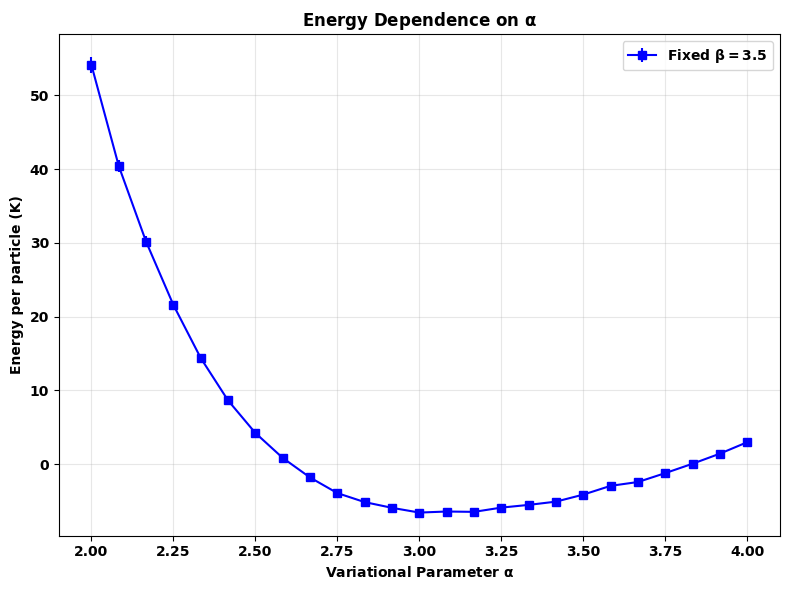

In [4]:
# SCAN ALPHA (Fixing Beta)
fixed_beta = 3.50
alphas_scan = np.linspace(2.0, 4.0, 25)
energies_alpha = []
errors_alpha = []

print(f"\nScanning Alpha (Fixed Beta = {fixed_beta})")
for a in alphas_scan:
    E_lap, _, acc_history, _ = VMC_simulation(N_STEPS, N_PARTICLES, a, fixed_beta, DELTA)
    
    # we discard the first 20% of points
    burn_idx = int(len(E_lap) * 0.2)
    valid_E = E_lap[burn_idx:]
    
    E_mean = np.mean(valid_E)
    E_err = np.std(valid_E) / np.sqrt(len(valid_E))
    
    energies_alpha.append(E_mean / N_PARTICLES)
    errors_alpha.append(E_err / N_PARTICLES)
    
    acc = np.mean(acc_history[burn_idx:])

    print(f"Alpha: {a:.2f} | E/N: {E_mean/N_PARTICLES:.4f} K | Acc: {acc:.1%}")

# Find best Alpha
min_idx_alpha = np.argmin(energies_alpha)
best_alpha = alphas_scan[min_idx_alpha]
min_E_alpha = energies_alpha[min_idx_alpha]
print(f"Optimal Alpha (at fixed beta={fixed_beta}): {best_alpha:.2f} (E = {min_E_alpha:.4f} K)")

# Plot 2: Energy vs Alpha
plt.figure(figsize=(8, 6))
plt.errorbar(alphas_scan, energies_alpha, yerr=errors_alpha, fmt='s-', color='blue', label=f'Fixed $\\beta={fixed_beta}$')
plt.title(f"Energy Dependence on $\\alpha$")
plt.xlabel(r"Variational Parameter $\alpha$")
plt.ylabel("Energy per particle (K)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

As donde by Boronat and Casulleras (1994), we are going to keep the optimal $\alpha$ result fixing $\beta$:

$$\alpha=3.08, \qquad \beta=3.50$$

## 2. Final VMC Simulation at Optimal Parameters

With the variational parameters optimized to $\alpha \approx 3.08$ and $\beta \approx 3.50$, we now perform a long (many MC steps) run to extract precise physical properties of the Superfluid Helium-4 ground state.

**Implementation details:**
1.  The first $20\%$ of the simulation trajectory is discarded to remove any bias from the initial lattice configuration.
2.  We compute the ground state energy using two independent energy (Laplacian & Gradient) estimators. A significant discrepancy between these two would indicate potential errors in the wavefunction derivatives or sampling issues.

VMC Simulation with Alpha=3.08, Beta=3.5...

SIMULATION RESULTS:
    Acceptance Rate:       44.5% (Target: 20-80%)
    Mean Energy (Lap):     -6.5111 +/- 0.0142 K
    Mean Energy (Grad):    -3.8019 K


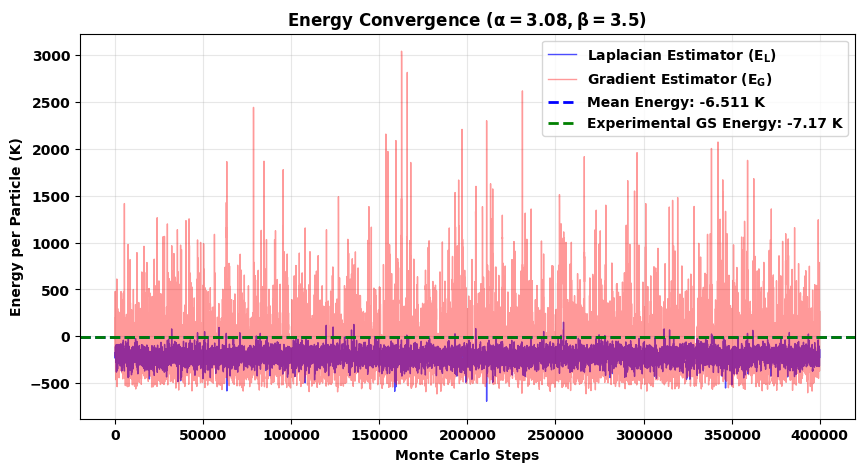

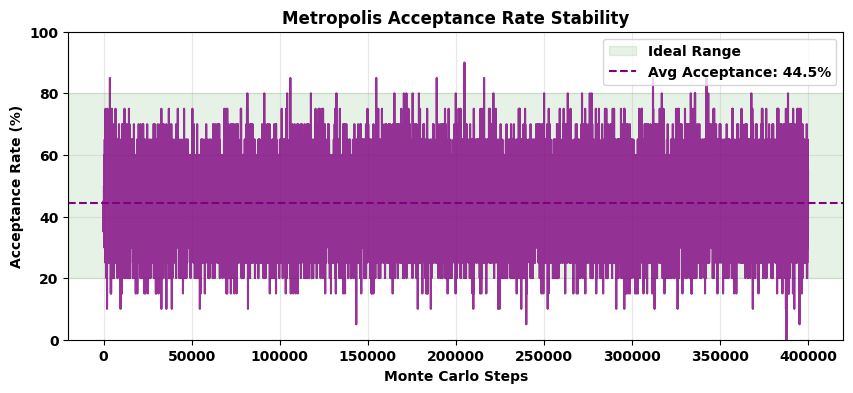

In [5]:
# SIMULATION PARAMETERS
OPT_ALPHA = 3.08
OPT_BETA = 3.50  
N_STEPS = 500000  # Number of MC steps
N_PARTICLES = 32  # Number of particles
DELTA = 1.0       # Step size (adjust ST acceptance is between 20-80%)

print(f"VMC Simulation with Alpha={OPT_ALPHA}, Beta={OPT_BETA}...")

# SIMULATION
E_lap_history, E_grad_history, acc_history, x_history = VMC_simulation(
    N_STEPS, N_PARTICLES, OPT_ALPHA, OPT_BETA, DELTA
)

# Discard first 20% of steps
burn_in = int(len(E_lap_history) * 0.2)
E_lap_stable = E_lap_history[burn_in:]
E_grad_stable = E_grad_history[burn_in:]
acc_stable = acc_history[burn_in:]

# Calculate Statistics
mean_E_lap = np.mean(E_lap_stable) / N_PARTICLES
mean_E_grad = np.mean(E_grad_stable) / N_PARTICLES
error_E = np.std(E_lap_stable) / np.sqrt(len(E_lap_stable)) / N_PARTICLES

print(f"\nSIMULATION RESULTS:")
print(f"    Acceptance Rate:       {np.mean(acc_stable)*100:.1f}% (Target: 20-80%)")
print(f"    Mean Energy (Lap):     {mean_E_lap:.4f} +/- {error_E:.4f} K")
print(f"    Mean Energy (Grad):    {mean_E_grad:.4f} K")

# PLOTTING
sample_interval = N_STEPS // len(E_lap_history)
steps_axis = np.arange(len(E_lap_history[burn_in:])) * sample_interval

# PLOT 1: LAPLACIAN VS GRADIENT ENERGIES
plt.figure(figsize=(10, 5))
plt.plot(steps_axis, E_lap_stable, label='Laplacian Estimator ($E_L$)', color='blue', alpha=0.7, linewidth=1)
plt.plot(steps_axis, E_grad_stable, label='Gradient Estimator ($E_G$)', color='red', alpha=0.4, linewidth=1)

plt.axhline(mean_E_lap, color='blue', linestyle='--', linewidth=2, label=f'Mean Energy: {mean_E_lap:.3f} K')

plt.axhline(-7.17, color='green', linestyle='--', linewidth=2, label=f'Experimental GS Energy: -7.17 K')

plt.xlabel('Monte Carlo Steps')
plt.ylabel('Energy per Particle (K)')
plt.title(f'Energy Convergence ($\\alpha={OPT_ALPHA}, \\beta={OPT_BETA}$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# PLOT 2: ACCEPTANCE RATE EVOLUTION
plt.figure(figsize=(10, 4))
plt.plot(steps_axis, acc_stable* 100, color='purple', alpha=0.8, linewidth=1.5)

plt.axhspan(20, 80, color='green', alpha=0.1, label='Ideal Range')
plt.axhline(np.mean(acc_stable)*100, color='purple', linestyle='--', label=f'Avg Acceptance: {np.mean(acc_stable)*100:.1f}%')

plt.xlabel('Monte Carlo Steps')
plt.ylabel('Acceptance Rate (%)')
plt.title('Metropolis Acceptance Rate Stability')
plt.ylim(0, 100)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# EXPORT DATA FOR g(r)
# x_history contains [n_samples, N_particles, 3]
final_positions = x_history[burn_in:]

# 3. Structural Analysis: Radial Distribution Function $g(r)$

The Radial Distribution Function, $g(r)$, describes the probability of finding a particle at a distance $r$ from a reference particle, relative to the probability expected for a completely random (ideal gas) distribution at the same density.

For the Helium-4 Atom, we expect the following behaviuor:
* **$r < 2.0$ Å (Hard Core):** $g(r)$ should be exactly zero, confirming that the strong repulsion in the Aziz potential (and the Jastrow factor) prevents particle overlap.
* **$r \approx 3.6$ Å (First Peak):** This peak represents the "nearest neighbor" shell.
* **$r \to \infty$ (Long Range):** For a liquid, $g(r)$ should oscillate and eventually converge to $1.0$, indicating a lack of long-range crystallographic order.

We compute $g(r)$ by histogramming all pair distances $r_{ij}$ from the equilibrated Monte Carlo trajectory:
$$g(r) = \frac{N(r, \Delta r)}{\rho \cdot V_{shell}(r)}$$
where:
* $N(r, \Delta r)$ is the number of pairs found in the spherical shell between $r$ and $r+\Delta r$.
* $\rho = N/L^3$ is the number density of the system.
* $V_{shell}(r) \approx 4\pi r^2 \Delta r$ is the volume of the shell.

In [6]:
@njit
def compute_gr(x_history, L, N, n_bins=100):
    """
    Computes the Pair Distribution Function g(r)
    """
    r_max = L / 2.0  # Max valid distance in PBC
    dr = r_max / n_bins

    gr_counts = np.zeros(n_bins)
    
    n_frames = x_history.shape[0]
    
    # Loop over all stored snapshots (frames)
    for t in range(n_frames):
        positions = x_history[t]
        
        # Loop over all pairs
        for i in range(N):
            for j in range(i + 1, N):
                _, r = pbc_dist(positions[i], positions[j], L)
                
                if r < r_max:
                    bin_idx = int(r / dr)   # index of the bin to which this distance belongs
                    if bin_idx < n_bins:
                        gr_counts[bin_idx] += 2.0 # +2 because (i,j) and (j,i) count
                        
    # Normalization
    rho = N / (L**3)  # Number density
    r_vals = np.linspace(dr/2, r_max - dr/2, n_bins)
    
    # Volume of each spherical shell: 4*pi*r^2*dr
    # More precise shell volume: (4/3)*pi*((r+dr)^3 - r^3)
    
    g_r = np.zeros(n_bins)
    for b in range(n_bins):
        r_inner = b * dr
        r_outer = (b + 1) * dr
        vol_shell = (4.0/3.0) * np.pi * (r_outer**3 - r_inner**3)
        
        # Expected number of particles in this shell for an ideal gas
        # factor n_frames * N = total number of "centers" we averaged over
        norm_factor = rho * vol_shell * n_frames * N
        
        if norm_factor > 0:
            g_r[b] = gr_counts[b] / norm_factor
            
    return r_vals, g_r

Computing g(r) over 20000 frames...


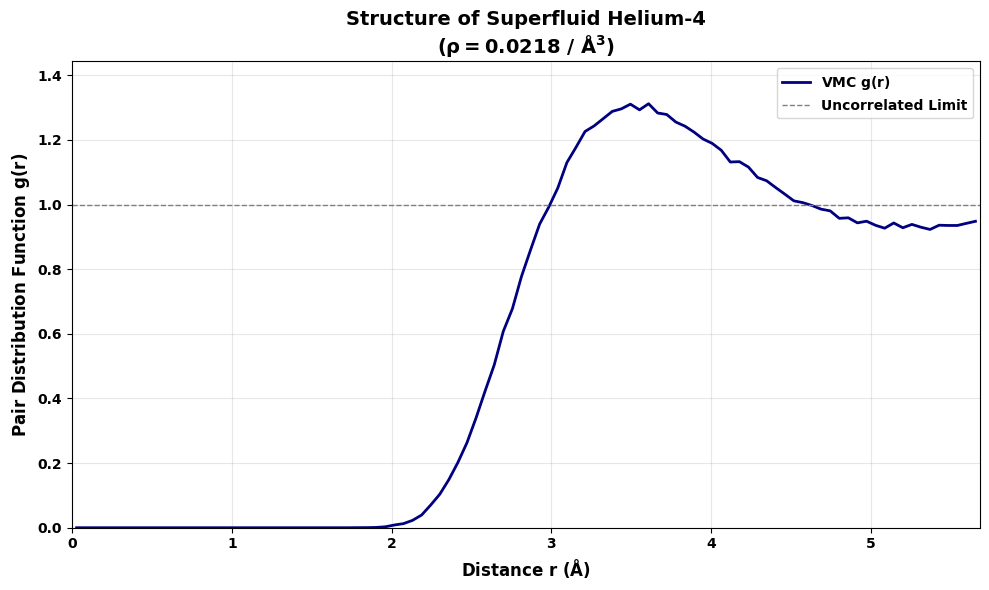

In [7]:
L_BOX = (N_PARTICLES / RHO_HE)**(1.0/3.0)

print(f"Computing g(r) over {len(final_positions)} frames...")
r_bins, gr_values = compute_gr(final_positions, L_BOX, N_PARTICLES, n_bins=100)

plt.figure(figsize=(10, 6))

# Main Plot
plt.plot(r_bins, gr_values, color='navy', linewidth=2, label='VMC $g(r)$')

# Guide (Ideal Gas = 1.0)
plt.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='Uncorrelated Limit')

# Formatting
plt.xlabel('Distance $r$ (Å)', fontsize=12)
plt.ylabel('Pair Distribution Function $g(r)$', fontsize=12)
plt.title(f'Structure of Superfluid Helium-4\n($\\rho = {RHO_HE}$ / Å$^{3}$)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, L_BOX/2.0)
plt.ylim(0, max(gr_values)*1.1)

plt.tight_layout()
plt.show()

## **Bonus**

As a final bonus, we plot the Aziz HFD-B potential for the final poster.

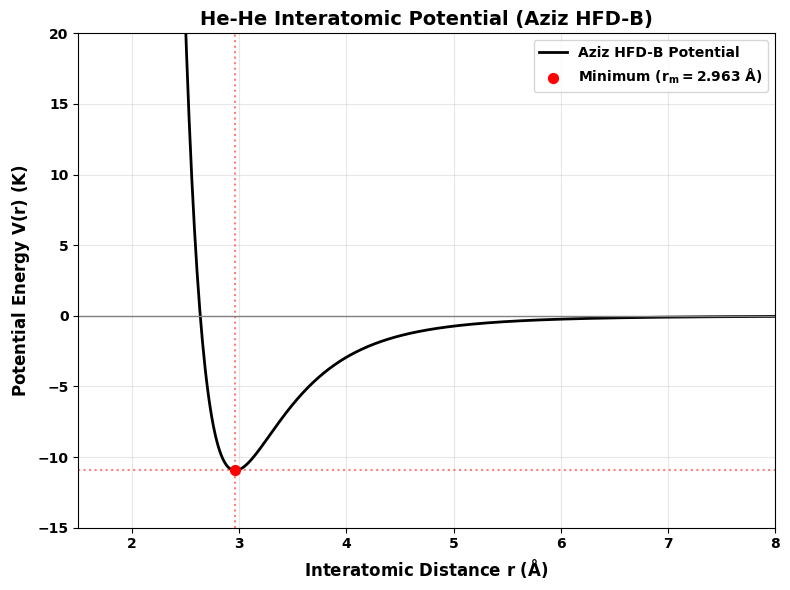

In [ ]:
# POTENTIAL FUNCTION
def aziz_potential(r):
    """
    Calculates the Aziz HFD-B potential energy in Kelvin.
    """
    x = r / RM
    
    # Initialize arrays
    V = np.zeros_like(x)
    
    # Repulsive Term
    # V_rep = A * exp(-alpha*x + beta*x^2)
    repulsion = A_REP * np.exp(-ALPHA_P * x + BETA_P * x**2)
    
    # Dispersion Term
    # Sum( C_n / x^n )
    dispersion_sum = (C6 / x**6) + (C8 / x**8) + (C10 / x**10)
    
    # Damping Function F(x)
    # F(x) = exp( -(D/x - 1)^2 ) for x < D
    # F(x) = 1.0                for x >= D
    F = np.ones_like(x)
    mask = x < D_DAMP
    F[mask] = np.exp(-(D_DAMP / x[mask] - 1)**2)
    
    # Total Potential
    # V(r) = epsilon * (Repulsion - F(x) * Dispersion)
    V = EPSILON * (repulsion - F * dispersion_sum)
    
    return V



# PLOTTING
r_vals = np.linspace(1.8, 8.0, 500)
V_vals = aziz_potential(r_vals)

plt.figure(figsize=(8, 6))

# Main Potential Curve
plt.plot(r_vals, V_vals, color='black', linewidth=2, label='Aziz HFD-B Potential')

# Mark the Minimum (r_m, -epsilon)
plt.scatter([RM], [-EPSILON], color='red', s=50, zorder=5, label=f'Minimum ($r_m={RM}$ Å)')
plt.axhline(-EPSILON, color='red', linestyle=':', alpha=0.5)
plt.axvline(RM, color='red', linestyle=':', alpha=0.5)

plt.axhline(0, color='gray', linewidth=1)

plt.title('He-He Interatomic Potential (Aziz HFD-B)', fontsize=14)
plt.xlabel('Interatomic Distance $r$ (Å)', fontsize=12)
plt.ylabel('Potential Energy $V(r)$ (K)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.ylim(-15, 20)
plt.xlim(1.5, 8.0)

plt.tight_layout()
plt.show()